# Latin Hypercube Sampling

The [LatinHypercube](https://grid.qcdevs.org/pyapi/grid.latin_hypercube.html#grid.latin_hypercube.LatinHypercube)
grid can be used for integration over a (hyper)cubic or parallelepiped domain.
Unlike the structured, tensor-product grids built from `onedgrid` classes, Latin
Hypercube Sampling (LHS) stratifies every one-dimensional marginal exactly:
splitting $[0,1)$ into $N$ equal strata along *any* single coordinate axis places
exactly one point in each stratum. This is a variance-reduction technique
(McKay, Beckman & Conover, 1979) rather than a classical quadrature rule, and it
scales *linearly* in the number of points regardless of dimension -- making it a
practical choice in the higher-dimensional settings (e.g. many uncertain
parameters) where tensor-product quadrature becomes infeasible.

## Initialization of LatinHypercube

`LatinHypercube` is initialized by specifying:

1. `n_points` -- the number of integration points $N$.
2. `dimension` -- the dimension $d$ of the integration domain.
3. `seed` (optional) -- for reproducibility.
4. `randomize` (optional, default `True`) -- if `True`, each point is jittered
   uniformly within its stratum; if `False`, each point is placed at the center
   of its stratum instead.
5. `origin` and `axes` (optional) -- to map the design from the unit hypercube
   $[0,1)^d$ onto an arbitrary parallelepiped.


## A 3D Scatter Plot of the Design

Each 1D projection (onto the x, y, or z axis) still places exactly one point
per stratum -- a property that is easy to state, but worth seeing directly in
three dimensions rather than just checking numerically.

In [21]:
from grid.latin_hypercube import LatinHypercube
import numpy as np

lhs3d = LatinHypercube(n_points=500, dimension=3, seed=0)
print(f"Number of points: {lhs3d.size}")
print(f"Points shape: {lhs3d.points.shape}")

Number of points: 500
Points shape: (500, 3)


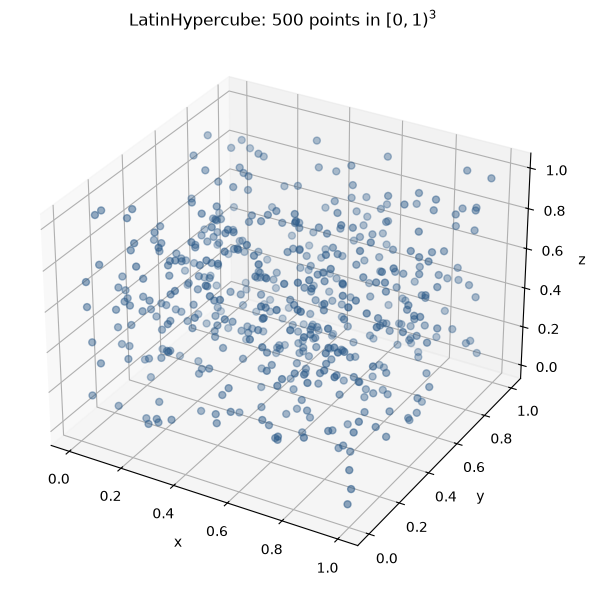

In [18]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401 (registers 3D projection)

fig = plt.figure(figsize=(7, 6))
ax = fig.add_subplot(111, projection="3d")
ax.scatter(
    lhs3d.points[:, 0], lhs3d.points[:, 1], lhs3d.points[:, 2],
    s=25, color="#2E5C8A", alpha=0.8, depthshade=True,
)
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("z")
ax.set_title(f"LatinHypercube: {lhs3d.size} points in $[0,1)^3$")
plt.tight_layout()
plt.show()

Setting `randomize=False` places each point exactly at the center of its
stratum instead of a random position within it (the assignment of strata to
dimensions is still randomized -- otherwise every dimension would place its
points on the same diagonal pattern).

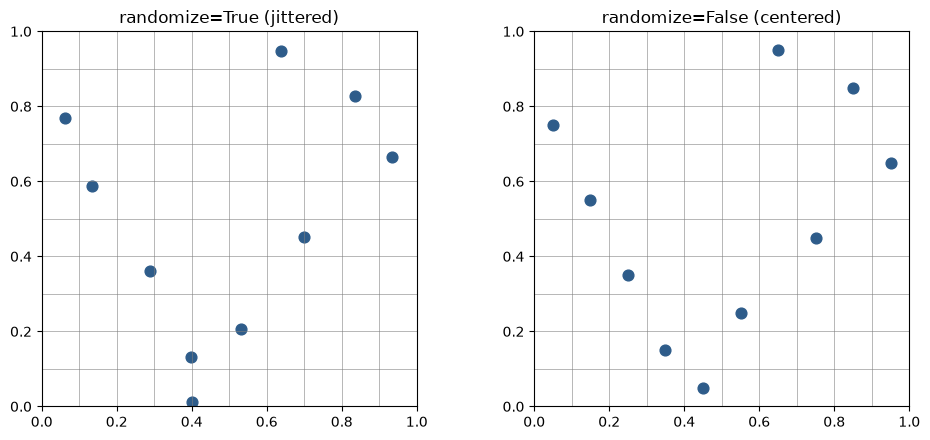

In [28]:
lhs_centered = LatinHypercube(n_points=10, dimension=2, seed=0, randomize=False)
lhs_random = LatinHypercube(n_points=10, dimension=2, seed=0, randomize=True)

import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))
for ax, grid, title in zip(
    axes, [lhs_random, lhs_centered], ["randomize=True (jittered)", "randomize=False (centered)"]
):
    ax.scatter(grid.points[:, 0], grid.points[:, 1], s=60, color="#2E5C8A")
    for k in range(1, n_points):
        ax.axhline(k / n_points, color="gray", lw=0.4)
        ax.axvline(k / n_points, color="gray", lw=0.4)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_aspect("equal")
    ax.set_title(title)
plt.tight_layout()
plt.show()

By default, points live on the unit hypercube $[0,1)^d$. Passing `origin` and
`axes` maps the design onto an arbitrary parallelepiped -- useful for integrating
over a specific molecular or parameter domain rather than the unit cube.

In [29]:
origin = np.array([1.0, 2.0])
axes = np.array([[3.0, 0.0], [0.0, 0.5]])
lhs_mapped = LatinHypercube(n_points=10, dimension=2, seed=0, origin=origin, axes=axes)

print(f"Points now lie in [1, 4) x [2, 2.5): "
      f"{(lhs_mapped.points[:, 0] >= 1).all() and (lhs_mapped.points[:, 0] < 4).all()}")
print(f"Weight per point (volume / N): {lhs_mapped.weights[0]:.4f}")

Points now lie in [1, 4) x [2, 2.5): True
Weight per point (volume / N): 0.1500


## Two Functions From Computational Chemistry

To compare Latin Hypercube Sampling against baselines already in `grid`, we use
two integrands that are both motivated by standard models in computational
chemistry, but differ in a property that matters a great deal for LHS: whether
the function is *additive*.

**1. Sum of independent harmonic oscillators (additive).** Within the harmonic
approximation, the vibrational potential energy of a molecule is a sum of
independent contributions from each normal mode:

$$\Phi(\mathbf{x}) = \sum_{i=1}^d \frac{1}{2} k_i x_i^2$$

This is a sum of one-variable functions -- exactly the structure that LHS is
provably better suited for than plain Monte Carlo (Stein, 1987): the variance of
the LHS estimator depends only on the *non-additive* residual of the integrand,
which is zero here.

**2. Product of Gaussian-type functions (non-additive).** Gaussian-type orbitals
(GTOs) are standard building blocks of quantum chemistry basis sets. A simple,
separable Gaussian orbital-like model over $d$ coordinates is

$$f(\mathbf{x}) = \prod_{i=1}^d \exp(-\alpha_i x_i^2)
= \exp\left(-\sum_{i=1}^d \alpha_i x_i^2\right)$$

In three dimensions, when $\alpha_1=\alpha_2=\alpha_3=\alpha$, this reduces to
$e^{-\alpha r^2}$, the radial form of a primitive $s$-type GTO, up to its
normalization constant. Unlike the harmonic sum, this is a *product*, not a
sum, of one-variable functions -- so it does not have the additive structure
LHS specifically exploits. Comparing both functions lets us see honestly where
LHS helps a great deal, and where it does not.

## Comparing Against Baselines Already in `grid`

We use `Tensor1DGrids`, built from three `Trapezoidal` 1D grids (`onedgrid`),
as a structured baseline already present in the library -- combined via a
simple tensor product, following the pattern used in `grid`'s own tests
(`test_point_and_weights_are_correct`). Note that, like `UniformGrid`,
`Tensor1DGrids` inherits from `_HyperRectangleGrid` and is restricted to two
or three dimensions -- one more reason to run this comparison at $d=3$.

`Trapezoidal` is defined on $[-1,1]$, so we remap its points and weights onto
$[0,1]^3$ with a simple affine transformation.

In [25]:
from scipy.special import erf

rng = np.random.default_rng(0)
DIM = 3

k = rng.uniform(0.5, 2.0, size=DIM)
alpha = rng.uniform(0.5, 3.0, size=DIM)


def harmonic_sum(x):
    # Sum of independent harmonic oscillators: Phi(x) = sum_i (1/2) k_i x_i^2.
    return 0.5 * (x**2 * k[None, :]).sum(axis=1)


def harmonic_sum_exact():
    # Exact integral over [0,1]^d.
    return k.sum() / 6.0


def gto_product(x):
    # Product of Gaussian-type functions: f(x) = prod_i exp(-alpha_i x_i^2).
    return np.exp(-(x**2 * alpha[None, :])).prod(axis=1)


def gto_product_exact():
    # Exact integral over [0,1]^d, via the error function.
    per_dim = (np.sqrt(np.pi) / (2 * np.sqrt(alpha))) * erf(np.sqrt(alpha))
    return per_dim.prod()


print(f"Exact integral of the harmonic sum:  {harmonic_sum_exact():.6f}")
print(f"Exact integral of the GTO product:   {gto_product_exact():.6e}")

Exact integral of the harmonic sum:  0.486930
Exact integral of the GTO product:   2.395592e-01


In [26]:
from grid.onedgrid import Trapezoidal
from grid.cubic import Tensor1DGrids
from grid.basegrid import Grid

N_VALUES_PER_AXIS = [3, 5, 7, 9, 12, 15]
N_TRIALS = 15

exact_add = harmonic_sum_exact()
exact_gto = gto_product_exact()

lhs_err_add, mc_err_add, tensor_err_add = [], [], []
lhs_err_gto, mc_err_gto, tensor_err_gto = [], [], []
n_points_list = []

for m in N_VALUES_PER_AXIS:
    N = m ** DIM
    n_points_list.append(N)

    trial_lhs_add, trial_mc_add = [], []
    trial_lhs_gto, trial_mc_gto = [], []
    for trial in range(N_TRIALS):
        lhs = LatinHypercube(n_points=N, dimension=DIM, seed=trial)
        trial_lhs_add.append(abs(lhs.integrate(harmonic_sum(lhs.points)) - exact_add))
        trial_lhs_gto.append(abs(lhs.integrate(gto_product(lhs.points)) - exact_gto))

        mc_points = np.random.default_rng(1000 + trial).random((N, DIM))
        mc_weights = np.full(N, 1.0 / N)
        mc_grid = Grid(mc_points, mc_weights)
        trial_mc_add.append(abs(mc_grid.integrate(harmonic_sum(mc_points)) - exact_add))
        trial_mc_gto.append(abs(mc_grid.integrate(gto_product(mc_points)) - exact_gto))

    lhs_err_add.append(np.mean(trial_lhs_add))
    mc_err_add.append(np.mean(trial_mc_add))
    lhs_err_gto.append(np.mean(trial_lhs_gto))
    mc_err_gto.append(np.mean(trial_mc_gto))

    oned = Trapezoidal(m)
    tensor = Tensor1DGrids(oned, oned, oned)
    # Trapezoidal lives on [-1, 1]; remap points and weights onto [0, 1]^3.
    tensor_points = (tensor.points + 1) / 2
    tensor_weights = tensor.weights / (2 ** DIM)
    tensor_grid = Grid(tensor_points, tensor_weights)
    tensor_err_add.append(abs(tensor_grid.integrate(harmonic_sum(tensor_points)) - exact_add))
    tensor_err_gto.append(abs(tensor_grid.integrate(gto_product(tensor_points)) - exact_gto))

print("Done.")

Done.


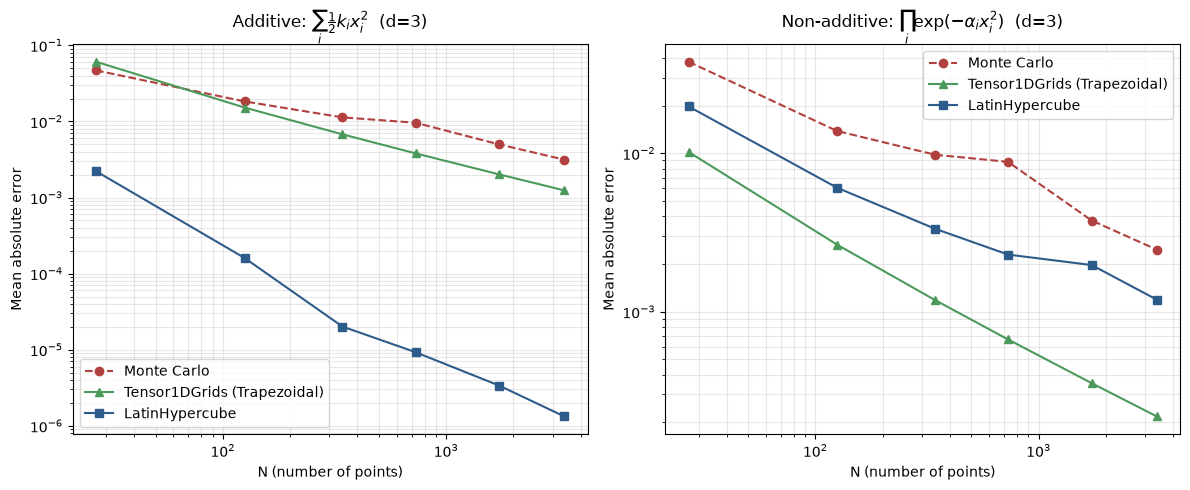

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].loglog(n_points_list, mc_err_add, "o--", color="#B0413E", label="Monte Carlo")
axes[0].loglog(n_points_list, tensor_err_add, "^-", color="#4C9A5B", label="Tensor1DGrids (Trapezoidal)")
axes[0].loglog(n_points_list, lhs_err_add, "s-", color="#2E5C8A", label="LatinHypercube")
axes[0].set_xlabel("N (number of points)")
axes[0].set_ylabel("Mean absolute error")
axes[0].set_title(r"Additive: $\sum_i \frac{1}{2} k_i x_i^2$" + f"  (d={DIM})")
axes[0].legend()
axes[0].grid(True, which="both", alpha=0.3)

axes[1].loglog(n_points_list, mc_err_gto, "o--", color="#B0413E", label="Monte Carlo")
axes[1].loglog(n_points_list, tensor_err_gto, "^-", color="#4C9A5B", label="Tensor1DGrids (Trapezoidal)")
axes[1].loglog(n_points_list, lhs_err_gto, "s-", color="#2E5C8A", label="LatinHypercube")
axes[1].set_xlabel("N (number of points)")
axes[1].set_ylabel("Mean absolute error")
axes[1].set_title(r"Non-additive: $\prod_i \exp(-\alpha_i x_i^2)$" + f"  (d={DIM})")
axes[1].legend()
axes[1].grid(True, which="both", alpha=0.3)

plt.tight_layout()
plt.show()

On the additive harmonic-oscillator sum, `LatinHypercube` outperforms both
plain Monte Carlo and the structured `Tensor1DGrids` baseline by a wide and
growing margin -- consistent with Stein's (1987) result for additive
integrands. On the non-additive GTO product, `Tensor1DGrids` performs best
(a smooth function is exactly the setting where structured, polynomial-exact
quadrature excels), with `LatinHypercube` a consistent second and plain Monte
Carlo last. Taken together, the two panels give an honest picture: LHS is not
universally the best choice, but it is the clear winner whenever the
integrand has meaningful additive structure, and it remains competitive even
when it does not.